# Séries Temporelles : fiche TP4
Thomas Besnier, Wilfried Heyse


## Etude de processus stationnaires ARMA
Nous étudions la série chronologique disponible dans le fichier AR.txt contenant un processus AR.

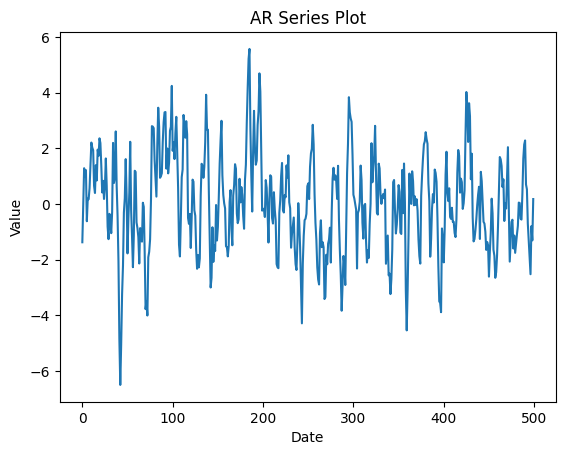

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read data from text file
with open("AR.txt", "r") as file:
    lines = file.readlines()

data = []
for line in lines[0:]:
    values = line.strip().split()
    data.extend([float(value) for value in values])

serie = pd.Series(data)
plt.plot(serie)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('AR Series Plot')
plt.show()

1. Observer les auto-corrélations empiriques (partielles ou non). Retrouvez les indices sur le type de processus.

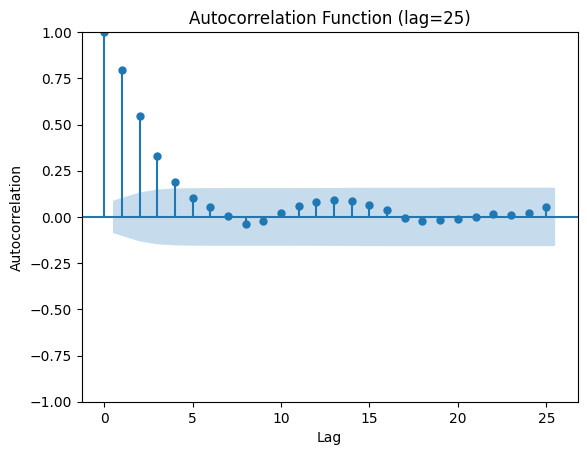

In [2]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(serie, lags=25, title='Autocorrelation Function (lag=25)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

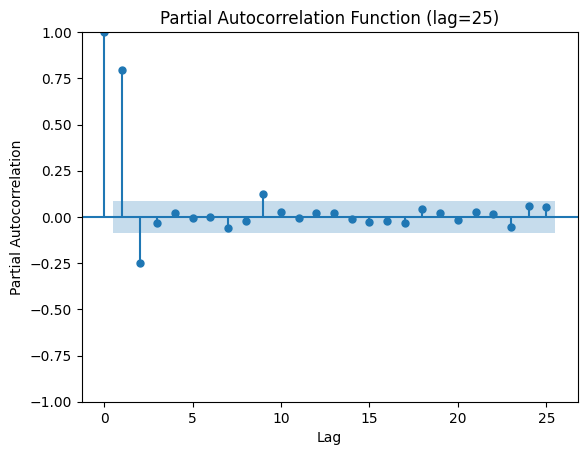

In [3]:
plot_pacf(serie, lags=25, title='Partial Autocorrelation Function (lag=25)')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.show()

Pour AR(2) -> ACF décroissante exponentiellement et pACF 2 pics différents de 0.

2. Estimez les coefficients du processus (on pourra utiliser la fonction arima sous R ou ARIMA disponible dans statsmodels.tsa.arima.model sous Python)

In [4]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(serie, order=(2, 0, 0))
model_fit = model.fit()

print("Estimated coefficients:", model_fit.params)

Estimated coefficients: const     0.042733
ar.L1     1.001392
ar.L2    -0.255531
sigma2    1.032850
dtype: float64


Le processus s'écrit donc (presque) $X_t = X_{t-1} - \frac{1}{4}X_{t-2} + \epsilon_t$.

3. Pour le processus AR, sachant que les coefficients choisits pour simuler le processus étaient 1 et $−\frac{1}{4}$, le processus était-il bien stationnaire ?

Oui, le polynome caractéristique associé est $A(z)=1−z−(−\frac{1}{4})z^2$ dont la racine, 2, est de module strictement supérieur à 1.

4. En vous basant sur l’analyse des résidus, la modélisations semble-t-elle fidèle aux données ?

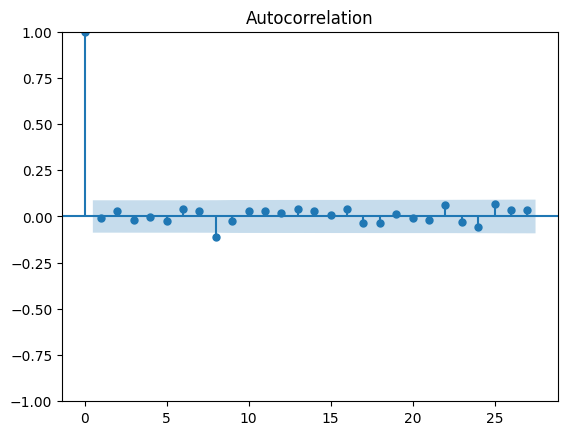

In [5]:
residus = model_fit.resid
plot_acf(residus)
plt.show()

In [6]:
from statsmodels.stats.diagnostic import acorr_ljungbox
box_pierce_test = acorr_ljungbox(residus, lags=[20], return_df=True, boxpierce=True)
print(box_pierce_test)

      lb_stat  lb_pvalue    bp_stat  bp_pvalue
20  13.480827   0.855814  13.162433   0.870306


For BP test,
- Null hypothesis (H0): The residuals are independently distributed (no autocorrelation).
- Alternative hypothesis (H1): The residuals are not independently distributed (there is autocorrelation).

Here, $p>0.05$, we keep H0.

5. Effectuez le même travail sur les processus des fichiers MA.txt et ARMA.txt

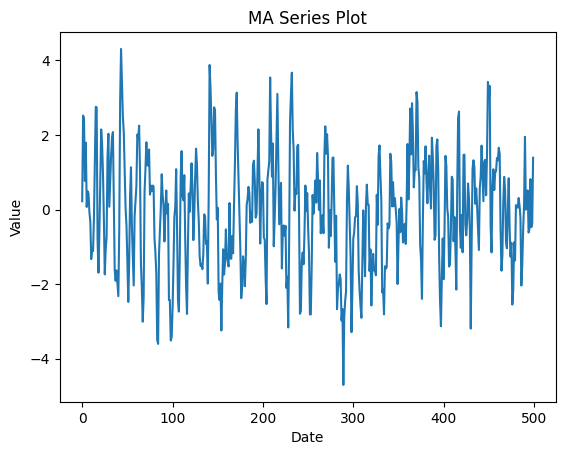

In [7]:
with open("MA.txt", "r") as file:
    lines = file.readlines()

data = []
for line in lines[0:]:
    values = line.strip().split()
    data.extend([float(value) for value in values])

serie = pd.Series(data)
plt.plot(serie)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('MA Series Plot')
plt.show()

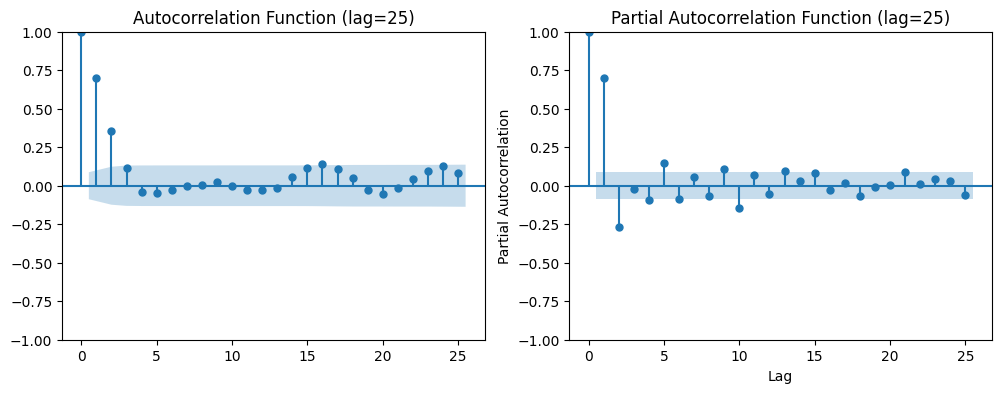

In [8]:
fig, ax = plt.subplots(1,2,figsize=(12, 4))
plot_acf(serie, lags=25, title='Autocorrelation Function (lag=25)', ax=ax[0])
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plot_pacf(serie, lags=25, title='Partial Autocorrelation Function (lag=25)', ax=ax[1])
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.show()

Pour MA(3) -> pACF décroissante exponentiellement et ACF 3 pics différents de 0.

In [9]:
model = ARIMA(serie, order=(0, 0, 3))
model_fit = model.fit()

print("Estimated coefficients:", model_fit.params)

Estimated coefficients: const    -0.072312
ma.L1     0.973675
ma.L2     0.530987
ma.L3     0.406068
sigma2    0.987023
dtype: float64


Le processus s’écrit donc $X_t=0.97\epsilon_{t−1}+0.53\epsilon_{t−2}+0.41\epsilon{t−3}+\epsilon_t$ avec $\epsilon_t$ un bruit blanc.

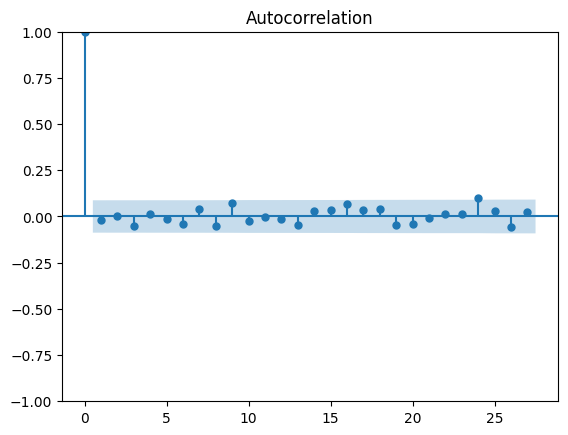

      lb_stat  lb_pvalue    bp_stat  bp_pvalue
20  15.616742   0.740098  15.180695   0.765976


In [10]:
residus = model_fit.resid
plot_acf(residus)
plt.show()
box_pierce_test = acorr_ljungbox(residus, lags=[20], return_df=True, boxpierce=True)
print(box_pierce_test)

Modèle validé !

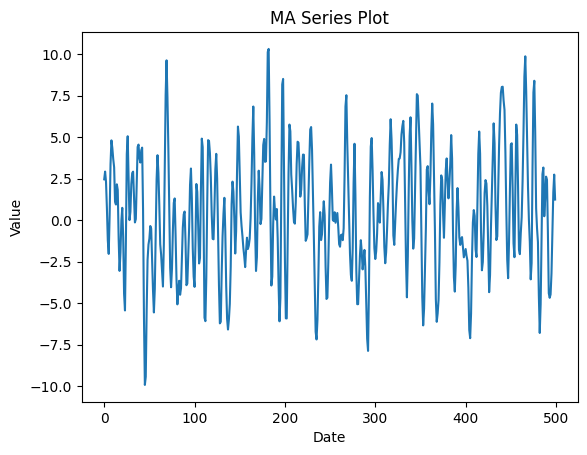

In [11]:
with open("ARMA.txt", "r") as file:
    lines = file.readlines()

data = []
for line in lines[0:]:
    values = line.strip().split()
    data.extend([float(value) for value in values])

serie = pd.Series(data)
plt.plot(serie)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('MA Series Plot')
plt.show()

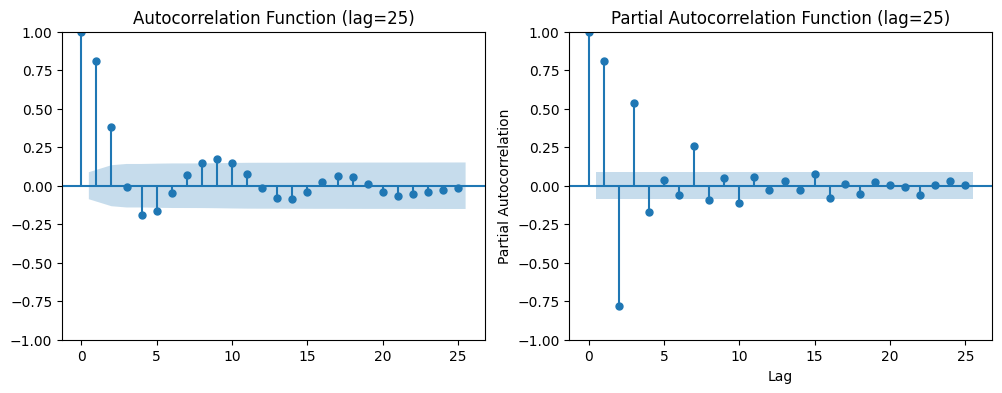

In [12]:
fig, ax = plt.subplots(1,2,figsize=(12, 4))
plot_acf(serie, lags=25, title='Autocorrelation Function (lag=25)', ax=ax[0])
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plot_pacf(serie, lags=25, title='Partial Autocorrelation Function (lag=25)', ax=ax[1])
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.show()

Pour ARMA(2,3) -> ACF 3-2 pic différent de 0 et ACF 2-3 pic différent de 0. (En pratique les graphes ne sont pas très parlant) Si doutes -> estimer plusieurs modèles et minimiser l’AIC (Akaike Information Criterion).

In [13]:
model = ARIMA(serie, order=(2, 0, 3))
model_fit = model.fit()

print("Estimated coefficients:", model_fit.params)

Estimated coefficients: const     0.407570
ar.L1     0.900899
ar.L2    -0.489416
ma.L1     1.164805
ma.L2     0.736710
ma.L3     0.475235
sigma2    1.042905
dtype: float64


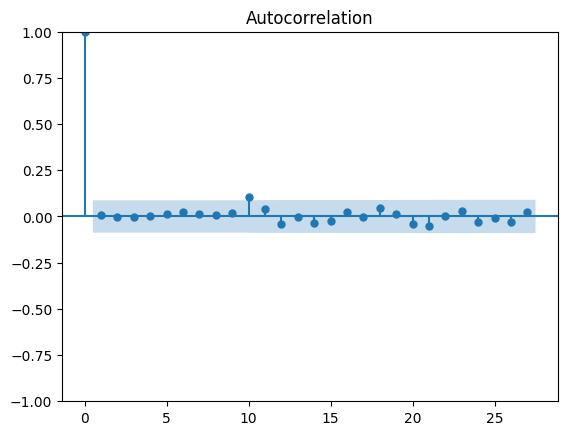

      lb_stat  lb_pvalue    bp_stat  bp_pvalue
20  11.685453   0.926477  11.358228   0.936398


In [14]:
residus = model_fit.resid
plot_acf(residus)
plt.show()
box_pierce_test = acorr_ljungbox(residus, lags=[20], return_df=True, boxpierce=True)
print(box_pierce_test)

Le processus s’écrit donc $X_t=0.9X_{t−1}−0.49X_{t−2}+1.16\epsilon_{t−1}+0.74\epsilon_{t−2}+0.48\epsilon_{t−3}+\epsilon_t$ avec $\epsilon_t$ un bruit blanc.

## Prédiction d'un processus

1. Ce processus vous semble-t-il modélisable par un processus ARMA ?

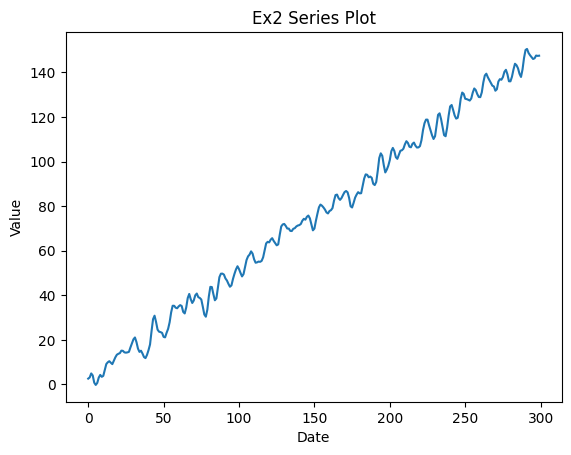

In [15]:
with open("Exercice2.txt", "r") as file:
    lines = file.readlines()

data = []
for line in lines[0:]:
    values = line.strip().split()
    data.extend([float(value) for value in values])

serie = pd.Series(data)
plt.plot(serie)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Ex2 Series Plot')
plt.show()

Non, le processus est clairement non-stationnaire.

2. On travaille désormais avec la série obtenue avec la méthode des différences à la série. Combien de fois faut-il appliquer la méthode ici ?

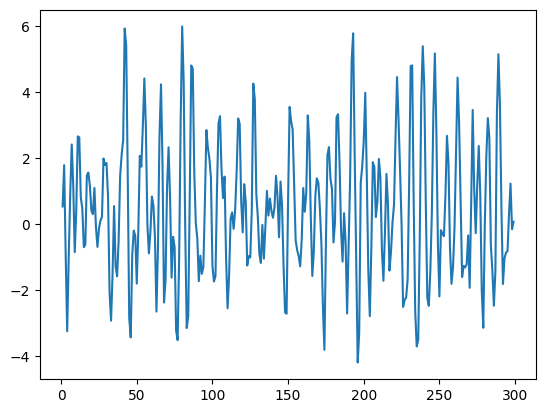

In [16]:
x1 = serie.diff(periods=1).dropna()  #1 diff car tendance linéaire (polynome de degré 1)
plt.plot(x1)
plt.show()

3. En observant les auto-corrélations empiriques et auto-corrélations partielles empiriques, proposer des modèles AR(p), MA(q) ou ARMA(p,q) d’ordre faible pour modéliser cette série.

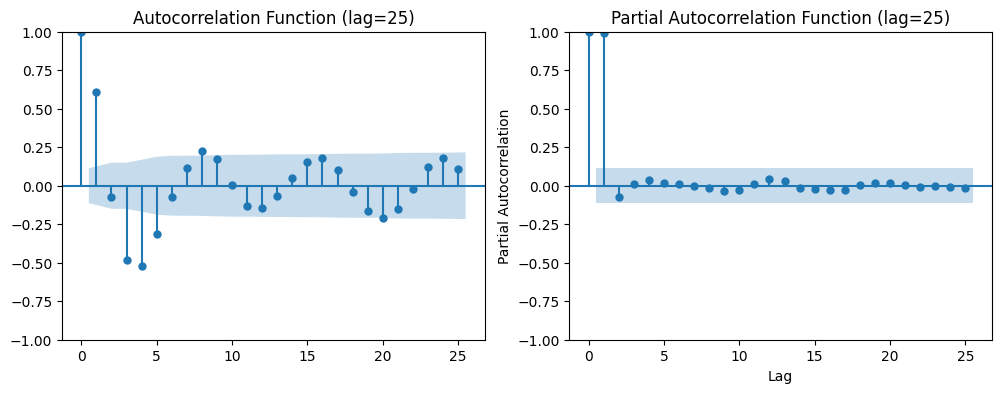

In [17]:
fig, ax = plt.subplots(1,2,figsize=(12, 4))
plot_acf(x1, lags=25, title='Autocorrelation Function (lag=25)', ax=ax[0])
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plot_pacf(serie, lags=25, title='Partial Autocorrelation Function (lag=25)', ax=ax[1])
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.show()

In [18]:
data_modele = pd.DataFrame(columns=["AR_p", "MA_q", "AIC"])
for p in range(4):
    for q in range(4):
        model = ARIMA(x1, order=(p, 0, q))
        model_fit = model.fit()
        aic = model_fit.aic
        data_modele = pd.concat([data_modele, pd.DataFrame({"AR_p": [p], "MA_q": [q], "AIC": [aic]})], ignore_index=True)
best_model = data_modele.loc[data_modele['AIC'].idxmin()]

print("Best ARMA model (p, q) with the lowest AIC:")
print(best_model)

/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: Val

/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/base/model

Best ARMA model (p, q) with the lowest AIC:
AR_p             2
MA_q             2
AIC     878.024972
Name: 10, dtype: object


/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


La meilleure config semble être pour ARMA(2,2).

4. Estimer les paramètres du modèle sélectionné.

In [19]:
model = ARIMA(x1, order=(2, 0, 2))
model_fit = model.fit()

print("Estimated coefficients:", model_fit.params)

Estimated coefficients: const     0.495987
ar.L1     1.218058
ar.L2    -0.587533
ma.L1    -0.174545
ma.L2    -0.825300
sigma2    1.035110
dtype: float64


/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


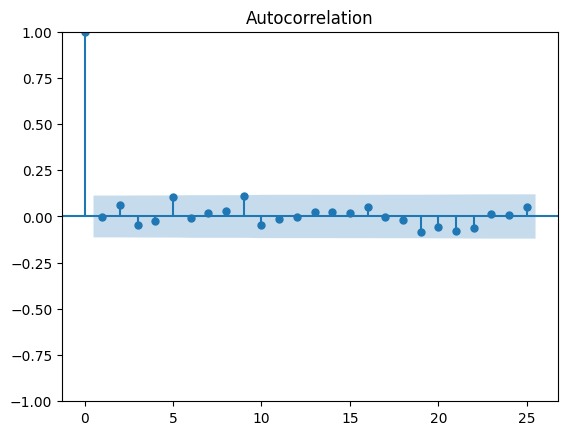

      lb_stat  lb_pvalue  bp_stat  bp_pvalue
20  15.256057   0.761573  14.6455    0.79632


In [20]:
residus = model_fit.resid
plot_acf(residus)
plt.show()
box_pierce_test = acorr_ljungbox(residus, lags=[20], return_df=True, boxpierce=True)
print(box_pierce_test)

6. Donnez une prévision pour les 20 temps suivants de la série et représentez vos prévisions.

In [21]:
forecast = model_fit.forecast(steps=20)

/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [22]:
### tendance
time = np.arange(0, len(serie))
import statsmodels.api as sm  # Linear regression

X = sm.add_constant(time)  # Add constant
model = sm.OLS(serie, X).fit()
tendance = model.params[1] * time + model.params[0]
tendance_forecast = model.params[1] * np.array(forecast.index) + model.params[0]

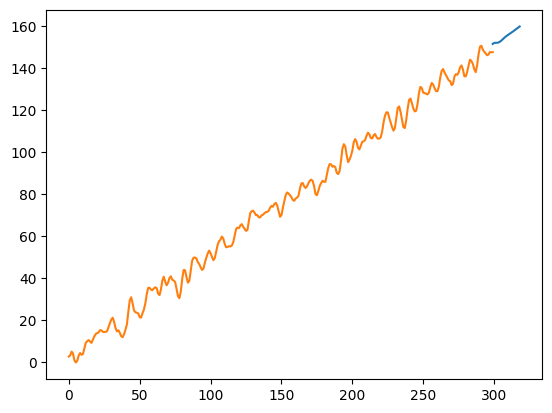

In [23]:
plt.plot(np.array(forecast.index), tendance_forecast + forecast)
plt.plot(serie)
plt.show()

## Précipitations mensuelles à San Fransisco entre 1932 et 1966

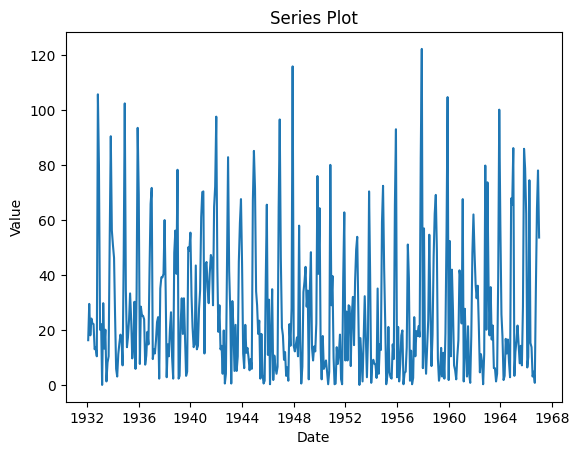

In [24]:
with open("SanFransisco.txt", "r") as file:
    lines = file.readlines()

data = []
for line in lines[0:]:
    values = line.strip().split()
    data.extend([float(value) for value in values])

serie = pd.Series(data)
serie.index = pd.date_range(start='1932-01-01', periods=len(serie), freq='M')
plt.plot(serie)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Series Plot')
plt.show()

1. La série semble-t-elle stationnaire ?

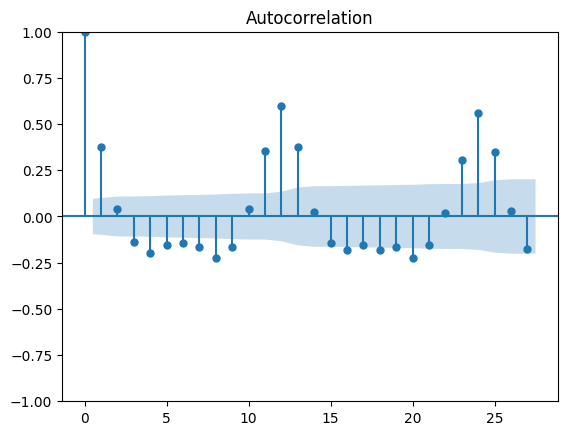

In [25]:
plot_acf(serie)
plt.show()

In [26]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(serie)

print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -4.185598593906692
p-value: 0.0006968778832111678
Critical Values:
   1%: -3.446722009322339
   5%: -2.868756617175256
   10%: -2.570614247667137


p-value less than 0.05, we reject the null hypothesis: we conclude that the series is stationnary.

2. Proposer un modèle pour cette série temporelle et justifier.

3. On propose de modéliser la série avec un SARIMA(2,0,0,12). Rappelez les caractéristiques de ce modèle

1. (p, d, q): These are the non-seasonal parameters.

    p: The number of lag observations included in the model (the order of the autoregressive part).
    
    d: The number of times that the raw observations are differenced (the degree of differencing).
    
    q: The size of the moving average window (the order of the moving average part).
    

2. (P, D, Q, s): These are the seasonal parameters.

    P: The number of lag observations included in the seasonal part of the model (the order of the seasonal autoregressive part).
    
    D: The number of times that the raw observations are seasonally differenced (the degree of seasonal differencing).
    
    Q: The size of the moving average window in the seasonal part of the model (the order of the seasonal moving average part).
    
    s: The periodicity (seasonal length), e.g., 12 for monthly data with an annual seasonal cycle.

3. Estimer le modèle SARIMA(2,0,0,12). Afficher et tester les résidus.

In [41]:
import statsmodels.api as sm
p, d, q = 4, 0, 2  # Non-seasonal parameters
P, D, Q, s = 4, 0, 2, 12  # Seasonal parameters

model = sm.tsa.SARIMAX(serie[:-36], order=(p, d, q), seasonal_order=(P, D, Q, s))
model_fit = model.fit()
print("Estimated coefficients:", model_fit.params)

/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/besnier/anaconda3/envs/GLDM/lib/python3.8/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           13     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.39069D+00    |proj g|=  7.27398D-02

At iterate    5    f=  4.36752D+00    |proj g|=  3.50485D-02

At iterate   10    f=  4.28809D+00    |proj g|=  1.02260D-01

At iterate   15    f=  4.25364D+00    |proj g|=  1.03445D-02

At iterate   20    f=  4.25312D+00    |proj g|=  6.98225D-04

At iterate   25    f=  4.25277D+00    |proj g|=  8.89165D-03

At iterate   30    f=  4.25247D+00    |proj g|=  7.85929D-04

At iterate   35    f=  4.25143D+00    |proj g|=  1.49781D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function 

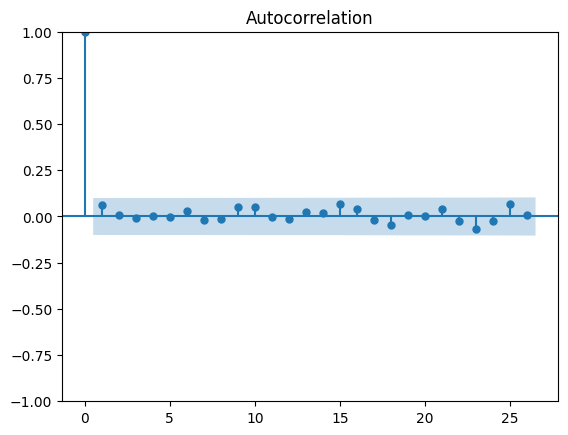

In [42]:
residus = model_fit.resid
plot_acf(residus)
plt.show()

4. Prévoir les précipitations de 1964, 1965 et 1966 à partir de ce modèle et représentez les.

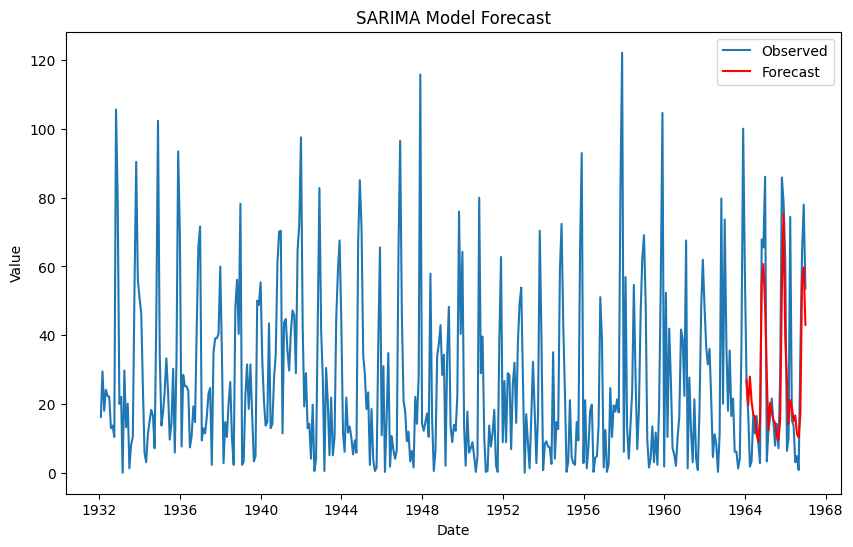

In [45]:
forecast_steps = 36  #3 years = 3*12 months
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

plt.figure(figsize=(10, 6))
plt.plot(serie, label='Observed')
plt.plot(forecast_mean, color='red', label='Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('SARIMA Model Forecast')
plt.legend()
plt.show()